In [2]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from scipy import integrate
#import h5py
#import plotly.express as px

In [3]:
def invariant(data):
    '''Calculates the invariant'''
    q = data[:,0]
    I = data[:,1]
    invariant = integrate.simpson(q**2*I, q)
    return invariant


def relative_coordinates(volume):
    '''This function is used to center any set of coordinates at the origin'''
    rel_x = volume[:,0] - np.mean(volume[:,0])
    rel_y = volume[:,1] - np.mean(volume[:,1])
    rel_z = volume[:,2] - np.mean(volume[:,2])
    relative_volume = np.hstack((rel_x.reshape(-1,1), rel_y.reshape(-1,1), rel_z.reshape(-1,1), volume[:,-1].reshape(-1,1)))
    return relative_volume

def rotation_angle(x,z):
    '''This function converts cartesian coordinates to polar'''
    angle = -np.arctan2(z, x)*180/math.pi
    return np.round(angle)

def amp_Calculate(inner, outer):
    '''This is used to find the mean diameter from the inner and outer ones'''
    return (inner+outer)*10/2/2

def rotate_coordinates_y(x, z, angle):
    '''This function performs a rigid body rotation around the y-axis'''
    angle = angle*math.pi/180
    x_new = x*np.cos(angle) + z*np.sin(angle)
    z_new = -x*np.sin(angle) + z*np.cos(angle)
    return x_new, z_new

def rotate_coordinates_x(y, z, angle):
    '''This function performs a rigid body rotation around the x-axis'''
    angle = angle*math.pi/180
    y_new = y*np.cos(angle) + z*np.sin(angle)
    z_new = -y*np.sin(angle) + z*np.cos(angle)
    return y_new, z_new

def rotate_coordinates_z(x, y, angle):
    '''This function performs a rigid body rotation around the z-axis'''
    angle = angle*math.pi/180
    x_new = x*np.cos(angle) + y*np.sin(angle)
    y_new = -x*np.sin(angle) + y*np.cos(angle)
    return x_new, y_new


def extract_data(file_path):
    """
    Extract numeric data from a .dat file.
    Skips comment lines starting with # or non-numeric rows.
    Returns numpy array and pandas DataFrame.
    """

    data = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith("#"):
                continue

            try:
                # Split by whitespace and convert to float
                row = [float(value) for value in line.split()]
                data.append(row)
            except ValueError:
                # Skip lines that can't be converted to float
                continue

    if not data:
        raise ValueError("No numeric data found in file.")

    data_array = np.array(data)

    # Create DataFrame with generic column names
    columns = [f"col_{i+1}" for i in range(data_array.shape[1])]
    df = pd.DataFrame(data_array, columns=columns)

    return data_array, df

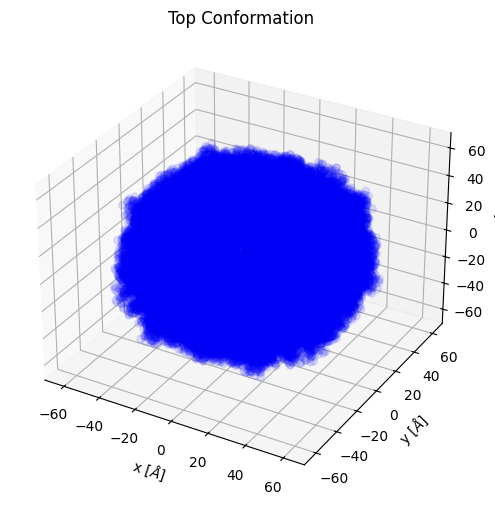

In [4]:
coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
coordinates = relative_coordinates(coordinates)
# Plotting
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')
ax.scatter(coordinates[:,0],coordinates[:,1],coordinates[:,2], color = 'blue', alpha = 0.1, s = 30)
ax.set_xlabel('x [$\\AA$]')
ax.set_ylabel('y [$\\AA$]')
ax.set_zlabel('z [$\\AA$]')
ax.set_title('Top Conformation')
building_block = coordinates

In [77]:
def generate_fcc_lattice(size, a):
    """
    Generate coordinates for a Face-Centered Cubic (FCC) lattice.

    Parameters
    ----------
    size : int or tuple of ints
        Number of unit cells in each direction.
        If int -> same size in x, y, z.
        If tuple -> (Nx, Ny, Nz)
    a : float
        Lattice constant (spacing between unit cell edges).

    Returns
    -------
    coords : ndarray of shape (N, 3)
        Cartesian coordinates of FCC lattice points.
    """

    # Allow cubic or rectangular lattice
    if isinstance(size, int):
        Nx = Ny = Nz = size
    else:
        Nx, Ny, Nz = size

    # FCC basis (fractional coordinates)
    basis = np.array([
        [0.0, 0.0, 0.0],
        [0.0, 0.5, 0.5],
        [0.5, 0.0, 0.5],
        [0.5, 0.5, 0.0]
    ])

    coords = []

    # Loop over unit cells
    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                cell_origin = np.array([i, j, k])
                for b in basis:
                    coords.append((cell_origin + b) * a)

    return np.array(coords)

def generate_sc_lattice(size, a):
    """
    Generate coordinates for a Simple Cubic (SC) lattice.

    Parameters
    ----------
    size : int or tuple of ints
        Number of unit cells in each direction.
    a : float
        Lattice constant.

    Returns
    -------
    coords : ndarray of shape (N, 3)
    """

    if isinstance(size, int):
        Nx = Ny = Nz = size
    else:
        Nx, Ny, Nz = size

    coords = []

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                coords.append([i * a, j * a, k * a])

    return np.array(coords)


def generate_bcc_lattice(size, a):
    """
    Generate coordinates for a Body-Centered Cubic (BCC) lattice.

    Parameters
    ----------
    size : int or tuple of ints
        Number of unit cells in each direction.
    a : float
        Lattice constant.

    Returns
    -------
    coords : ndarray of shape (N, 3)
    """

    if isinstance(size, int):
        Nx = Ny = Nz = size
    else:
        Nx, Ny, Nz = size

    # BCC basis (fractional coordinates)
    basis = np.array([
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.5]
    ])

    coords = []

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                cell_origin = np.array([i, j, k])
                for b in basis:
                    coords.append((cell_origin + b) * a)

    return np.array(coords)

    

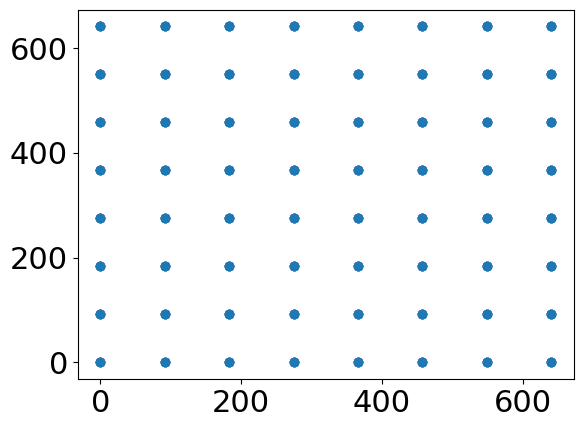

In [171]:
lattice_coordinates = generate_fcc_lattice(4, 183)
#lattice_coordinates = generate_bcc_lattice(10, 210)
#lattice_coordinates = generate_sc_lattice(10, 125)
plt.scatter(lattice_coordinates[:,0], lattice_coordinates[:,1])

In [172]:
n_samples = 10000000
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(building_block)
simulator.sample_lattice_coordinates(lattice_coordinates)
simulator.calculate_structure_coordinates()
histogram_bins = 10000
q = np.geomspace(0.005, 0.5, 3000)

I_q = np.mean(simulator.simulate_multiple_scattering_curves_lattice_coords(building_block, lattice_coordinates, histogram_bins, q, save=False).numpy(),axis=1)
#I_q = simulator.simulate_scattering_curve_fast_lattice(building_block, lattice_coordinates, histogram_bins, q, save=False).reshape(-1,1)

Text(0.5, 0, 'q ($\\AA^{-1}$)')

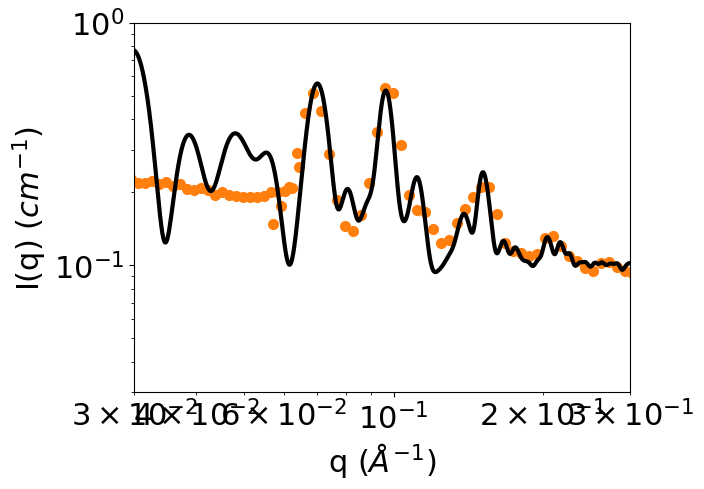

In [179]:
plt.rcParams.update({'font.size': 22})
#exp_data = extract_data('../Data/ferritin/2a_HuHF_crystalline_I(q).txt')[0]
exp_data = extract_data('../Data/ferritin/2a_PIX_crystalline_I(q).txt')[0]

background = 1e-1
plt.plot(q, I_q*2.0e-4 + background, linewidth = 3, label = 'MC-DFM', color='k')
plt.errorbar(
    exp_data[:,0], exp_data[:,1],
    yerr=exp_data[:,2],
    fmt='o',
    markersize=7,
    capsize=2,
    elinewidth=1,
    color = 'C1',
    ecolor='C1',
    zorder=0
)
plt.xlim([0.03, 0.3])
plt.ylim([0.03, 1])
plt.yscale('log')
plt.xscale('log')
plt.ylabel('I(q) ($cm^{-1}$)')
plt.xlabel('q ($\\AA^{-1}$)')

To confirm which object the scattering curve belongs to, we can plot the randomly sampled coordiantes used to create the pairwise distribution. As expected, the object is the tube like structure made from assembling the RhuA protein. 

Text(0, 0.5, 'z axis [$\\AA$]')

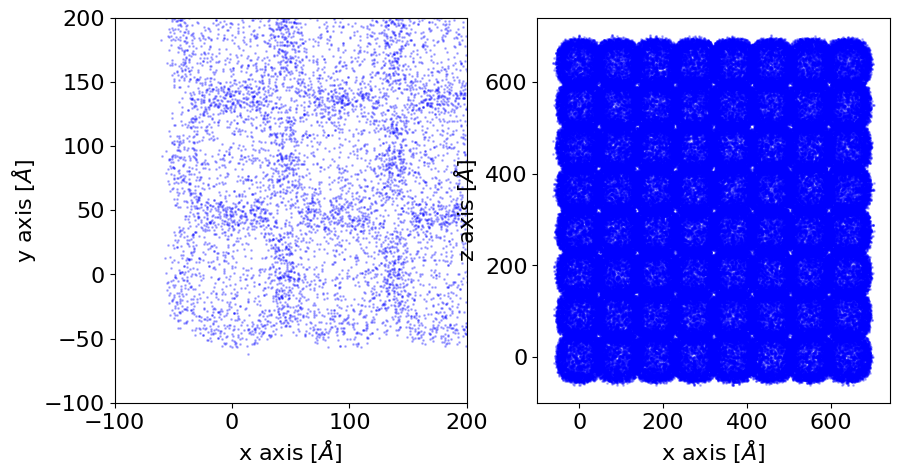

In [176]:
struc = simulator.structure_coordinates_1
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,5), ncols=2, nrows=1)
ax[0].scatter(struc[:,0][::50], struc[:,1][::50], alpha = 0.25, s=1, color = 'blue')
ax[0].set_xlim([-100,200])
ax[0].set_ylim([-100,200])
ax[0].set_xlabel('x axis [$\\AA$]')
ax[0].set_ylabel('y axis [$\\AA$]')
ax[1].scatter(struc[:,0][::10], struc[:,2][::10], alpha = 0.25, s=1, color = 'blue')
#ax[1].set_xlim([-100,200])
#ax[1].set_ylim([-100,200])
ax[1].set_xlabel('x axis [$\\AA$]')
ax[1].set_ylabel('z axis [$\\AA$]')

#plt.savefig('../Images/Sampled_Electron_Density_Tube_assembly_2.png', dpi=300, bbox_inches="tight")